In [1]:
import json
import numpy as np 
from matplotlib import pyplot as plt

In [2]:
def read_data(model_name, dataset_name, layer, basis_name):
    
    with open(f"../../artifacts/2024-10-s41/experiments/accuracy-basis/run1/{dataset_name}/{model_name}/{layer}/{basis_name}--uncentered/accuracy.json", "r") as fh:
        return json.load(fh)

read_data(model_name="cifar100-resnet18-v1", dataset_name="cifar100-people-and-others", layer="layer4", basis_name="pca")

{'accuracies': [0.1666666716337204,
  0.3033333420753479,
  0.5183333158493042,
  0.5950000286102295,
  0.628333330154419,
  0.6433333158493042,
  0.653333306312561,
  0.6516666412353516,
  0.6583333611488342,
  0.6583333611488342,
  0.6616666913032532,
  0.6633333563804626,
  0.6650000214576721,
  0.6600000262260437,
  0.6600000262260437,
  0.6616666913032532,
  0.6616666913032532,
  0.6650000214576721,
  0.6650000214576721,
  0.6633333563804626,
  0.6650000214576721,
  0.6650000214576721,
  0.6650000214576721,
  0.6633333563804626,
  0.6633333563804626,
  0.6600000262260437,
  0.6616666913032532,
  0.6600000262260437,
  0.6600000262260437,
  0.6583333611488342,
  0.6600000262260437,
  0.6583333611488342,
  0.6583333611488342,
  0.6566666960716248,
  0.6566666960716248,
  0.6566666960716248,
  0.6549999713897705,
  0.6549999713897705,
  0.6549999713897705,
  0.6549999713897705,
  0.6549999713897705,
  0.6549999713897705,
  0.6549999713897705,
  0.6549999713897705,
  0.6549999713897705

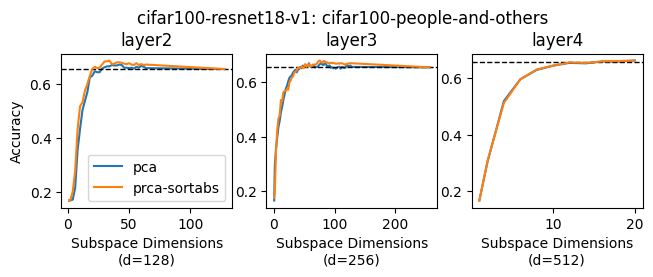

In [13]:
def viz(model_name, dataset_name, arr_layers=["layer2", "layer3", "layer4:20"]):
    ncols = len(arr_layers)
    
    
    plt.figure(figsize=(2.5*ncols, 2))
    plt.suptitle(f"{model_name}: {dataset_name}", y=1.10)
    
    for lix, layer in enumerate(arr_layers):
        plt.subplot(1, ncols, lix +1)
        slugs = layer.split(":")
        if len(slugs) == 2:
            layer, K = slugs
            K = int(K)
        else:
            layer = slugs[0]
            K = None
        plt.title(layer)
        if lix == 0:
            plt.ylabel("Accuracy")
        for bix, basis_name in enumerate(["pca", "prca-sortabs"]):
            data = read_data(model_name, dataset_name, layer, basis_name)
            best_acc = data["original_accuracy"]
            arr_ks = np.array(data["arr_ks"])
            d = arr_ks[-1]
            arr_accs = np.array(data["accuracies"])
        
            if K is not None:
                selected = arr_ks <= K
                arr_ks = arr_ks[selected]
                arr_accs = arr_accs[selected]
            plt.plot(arr_ks, arr_accs, label=basis_name)
            if bix == 0:
                plt.axhline(best_acc, ls="--", lw=1, color="k")
        plt.xlabel(f"Subspace Dimensions\n(d={d})")
        if lix == 0:
            plt.legend()

viz("cifar100-resnet18-v1", "cifar100-people-and-others")

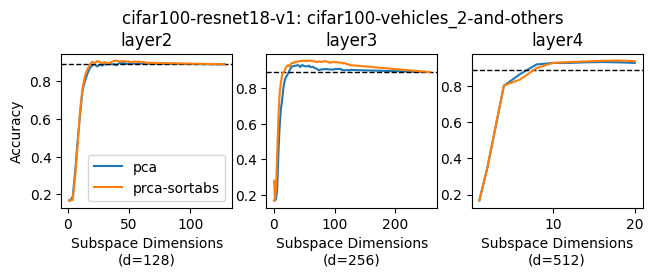

In [14]:
viz("cifar100-resnet18-v1", "cifar100-vehicles_2-and-others")

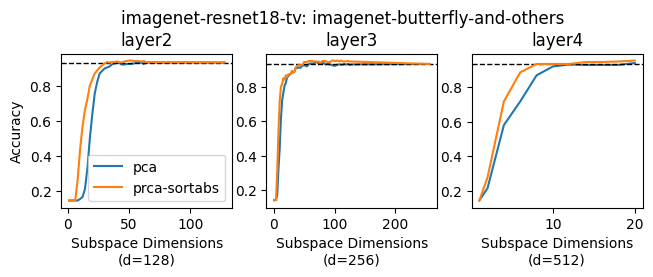

In [15]:
viz("imagenet-resnet18-tv", "imagenet-butterfly-and-others")

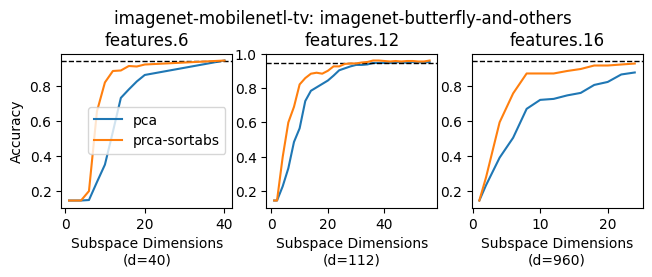

In [16]:
viz("imagenet-mobilenetl-tv", "imagenet-butterfly-and-others", 
    arr_layers=[
        "features.6",
        "features.12:64",
        "features.16:25",
    ])

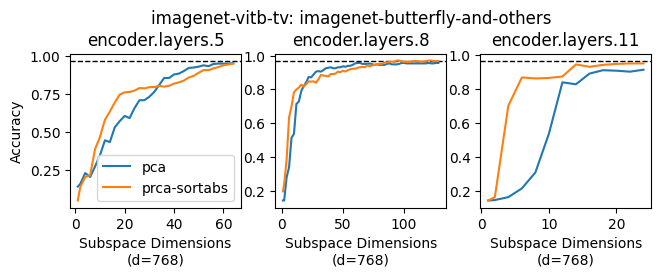

In [17]:
viz("imagenet-vitb-tv", "imagenet-butterfly-and-others", 
    arr_layers=[
        "encoder.layers.5:64",
        "encoder.layers.8:128",
        "encoder.layers.11:25"
    ])

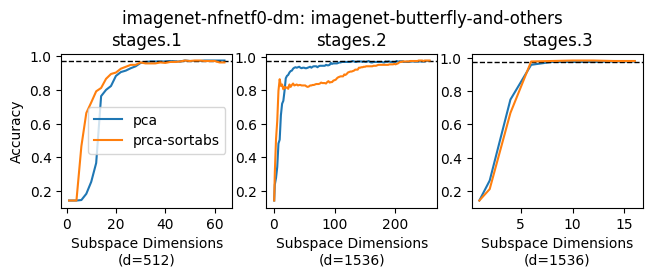

In [18]:
viz("imagenet-nfnetf0-dm", "imagenet-butterfly-and-others", 
    arr_layers=[
        "stages.1:64",
        "stages.2:256",
        "stages.3:16",
    ])